In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)
options(jupyter.plot_scale = 1)

In [2]:
tools = c('singlem', 'sylph', 'singlem_dev', 'singlem_joint_ee20bc')#, 'singlem_inject_ee20bc', 'singlem_nnls_ee20bc')
publication_names = data.table(
    tool = tools,
    publication_name = c('SingleM', 'sylph', 'SingleM dev', 'SingleM joint')#, 'SingleM inject', 'SingleM nnls')
)
communities = paste0('sample',as.character(c(0, 4, 5)))
known_percent = c(0, 10, 50, 70, 100)
percent_dominance = c(10, 50)
d1 = data.table(expand.grid(tool = tools, community = communities, known = known_percent, dom = percent_dominance))
d1[, tool2 := publication_names[tool, on = "tool", publication_name]]
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(tool, community, known, dom){
    to_read = paste0('output_',tool,'/opal/known', known, '/dominance', dom, '/', community,'.opal_report')
    return(fread(to_read))
}
d2 = d1[known != 0 | tool != "sylph" | community != "sample5", readit(tool, community, known, dom), by=list(tool, community, known, dom, tool2)]

ERROR: Error in fread(to_read): File 'output_singlem/opal/known0/dominance10/sample0.opal_report' does not exist or is non-readable. getwd()=='/mnt/hpccs01/home/lamber22/git/singlem-benchmarking/10_related_and_novel'


In [ ]:
names(d2)

[1] "tool"      "community" "known"     "dom"       "tool2"     "tool"     
 [7] "rank"      "metric"    "sample"    "value"

In [ ]:
setnames(d2, c("tool"), c("tool1"))
setnames(d2, c("tool"), c("blah"))
setnames(d2, c("tool1"), c("tool"))
d3 = d2[blah != 'Gold standard', .(tool, community, known, dom, rank, metric, value, tool2)]
d3[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]

Warning message in setnames(d2, c("tool"), c("tool1")):
“Item 1 of 'old' is 'tool' which appears several times in column names. Just the first will be changed. There are 0 other items in 'old' that are also duplicated in column names.”


In [ ]:
s1 = dcast(d3[!is.na(rank)], ...~metric, value.var='value')
s1[, c("tool", "tool2") := list(tool2, NULL)]

s1 = s1[order(rank, tool)]
fwrite(s1, 'opal_summary.csv', sep='\t')

Warning message:
“Removed 19 rows containing missing values or values outside the scale range
(`geom_line()`).”


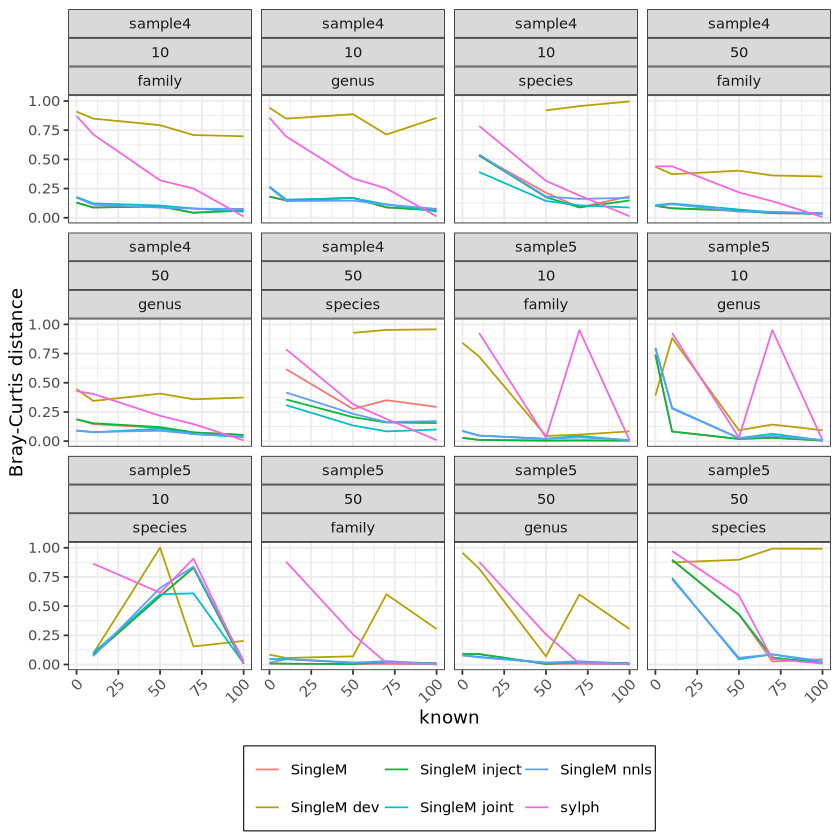

In [ ]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
ggplot(s1[rank %in% c("species", "genus", "family")],
       aes(known, `Bray-Curtis distance`, colour = tool)) +
   geom_line() +
   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
   theme(legend.title=element_blank()) +
   theme(legend.position="bottom") +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3)) +
   facet_wrap(vars(community, factor(dom), rank))

# Relationship between relative abundance and accuracy

In [ ]:
truth_profiles = data.table(expand.grid(community=communities, known=known_percent,
                                        dom = percent_dominance))
truth_profiles2 = truth_profiles[
    ,
    fread(paste('truths/known', known, '/dominance', dom, '/',community,'.condensed',sep=''),
          colClasses = c("coverage" = "double")),
    by=list(community, known, dom)
]
truth_profiles2[, c("sample", "tool") := .(NULL, 'Gold standard')]

In [ ]:
tool_profiles = data.table(expand.grid(tool = tools, community = communities,
                                       known = known_percent, dom = percent_dominance))
tool_profiles2 = tool_profiles[
    ,
    fread(paste('output_',tool,'/',tool,'/known', known, '/dominance', dom, '/', community,'.profile',sep='')),
    by=list(tool, community, known, dom)
]
tool_profiles2[
    ,
    `:=`(sample = NULL,
         taxonomy = gsub('Root;','',gsub('; ',';',taxonomy)),
         tool = factor(publication_names[tool, on = "tool", publication_name]))
]

all_profiles = rbind(truth_profiles2, tool_profiles2)
all_profiles[, relabu := coverage / sum(coverage), by = list(community, known, tool)]
m = dcast(all_profiles, taxonomy + community + known + dom ~ tool, value.var = c("relabu", "coverage"), fill = 0)
setnames(m, names(m), gsub("_", "__", names(m)))
setnames(m, c("relabu__Gold standard", "coverage__Gold standard"), c("true_relabu", "true_coverage"))

In [ ]:
# singlem and sylph relative abundances
format_table <- function(m) {
    ra_cols <- grep("^relabu_|_relabu$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^coverage_|_coverage$", names(m))), with = FALSE]
    mtmp[
        ,
        c(ra_cols, "taxonomy") := c(
            lapply(.SD, scales::label_percent()),
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = ra_cols
    ][order(community, known, taxonomy)]
}

In [ ]:
# singlem coverages
format_table_cov <- function(m) {
    cov_cols <- grep("^coverage_|_coverage$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^relabu_|_relabu$", names(m))), with = FALSE]
    mtmp[
        ,
        c(cov_cols, "taxonomy") := c(
            .SD,
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = cov_cols
    ][order(community, known, taxonomy)]
}

In [ ]:
# kingdom
#format_table(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, known, dom, taxonomy = gsub(";p__.*", "", taxonomy))])
format_table_cov(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, known, dom, taxonomy = gsub(";p__.*", "", taxonomy))])

community,known,dom,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,10,d__Archaea,3.0,3.41,3.16,2.31,0.000
sample4,0,50,d__Archaea,0.0,0.00,0.45,0.00,0.000
sample4,0,10,d__Bacteria,72.0,68.97,66.25,43.00,6.232
sample4,0,50,d__Bacteria,75.0,75.39,72.43,52.55,15.543
sample4,10,10,d__Archaea,0.0,0.53,0.50,0.00,0.000
sample4,10,50,d__Archaea,0.0,0.00,0.23,0.00,0.000
sample4,10,10,d__Bacteria,75.0,72.49,67.85,55.72,19.939
sample4,10,50,d__Bacteria,75.0,74.51,72.28,47.25,16.363
sample4,50,10,d__Archaea,0.0,0.00,0.26,0.00,0.000


In [ ]:
# phylum
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";c__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";c__.*", "", taxonomy))])

community,known,taxonomy,dom,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,d__Bacteria; p__Acidobacteriota,250,3.0,3.07,0.10,3.27,0.000
sample4,0,d__Bacteria; p__Actinobacteriota,680,51.0,49.18,39.25,35.33,12.749
sample4,0,d__Bacteria; p__Bacteroidota,700,30.0,29.50,15.56,16.37,0.000
sample4,0,d__Bacteria; p__Campylobacterota,150,3.0,3.41,1.11,2.52,0.000
sample4,0,d__Bacteria; p__Chlamydiota,150,3.0,1.99,0.00,0.00,0.000
sample4,0,d__Bacteria; p__Cyanobacteria,100,6.0,3.91,0.00,3.11,0.000
sample4,0,d__Bacteria; p__Firmicutes,30,3.0,2.05,0.00,1.33,0.000
sample4,0,d__Bacteria; p__Firmicutes_A,350,12.0,11.38,2.19,8.76,0.000
sample4,0,d__Bacteria; p__Firmicutes_E,20,3.0,0.51,0.00,0.00,0.000


In [ ]:
# class
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";o__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";o__.*", "", taxonomy))])

community,known,taxonomy,dom,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,p__Acidobacteriota; c__UBA4820,200,3.0,2.96,0.10,3.27,0.000
sample4,0,p__Actinobacteriota; c__Actinomycetia,670,51.0,48.67,39.25,35.33,12.749
sample4,0,p__Bacteroidota; c__Bacteroidia,500,24.0,24.44,13.14,13.73,0.000
sample4,0,p__Bacteroidota; c__Ignavibacteria,100,3.0,2.22,0.00,1.89,0.000
sample4,0,p__Bacteroidota; c__Kapabacteria,40,3.0,2.11,0.00,0.75,0.000
sample4,0,p__Campylobacterota; c__Campylobacteria,150,3.0,3.41,1.11,2.52,0.000
sample4,0,p__Chlamydiota; c__Chlamydiia,150,3.0,1.99,0.00,0.00,0.000
sample4,0,p__Cyanobacteria; c__Sericytochromatia,40,3.0,1.98,0.00,1.95,0.000
sample4,0,p__Cyanobacteria; c__Vampirovibrionia,50,3.0,1.65,0.00,1.16,0.000


In [ ]:
# order
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";f__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";f__.*", "", taxonomy))])

community,known,taxonomy,dom,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,c__Actinomycetia; o__Mycobacteriales,230,6.0,5.67,0.00,3.10,0.000
sample4,0,c__Actinomycetia; o__Nitriliruptorales,40,3.0,1.98,0.00,1.31,0.000
sample4,0,c__Actinomycetia; o__Streptomycetales,340,42.0,37.04,28.16,30.92,12.749
sample4,0,c__Alphaproteobacteria; o__RF32,100,3.0,3.13,0.64,2.22,0.000
sample4,0,c__Alphaproteobacteria; o__Rhodobacterales,20,3.0,2.28,0.00,1.77,0.000
sample4,0,c__Alphaproteobacteria; o__Rhodospirillales,40,3.0,2.25,0.00,1.83,0.000
sample4,0,c__Bacilli; o__Bacillales_H,20,3.0,1.99,0.00,1.33,0.000
sample4,0,c__Bacteroidia; o__Bacteroidales,220,15.0,15.68,4.64,8.35,0.000
sample4,0,c__Bacteroidia; o__Cytophagales,40,3.0,3.13,0.00,2.08,0.000


In [ ]:
# family
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";g__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";g__.*", "", taxonomy))])

community,known,taxonomy,dom,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,o__Bacillales_H; f__Bacillaceae_F,20,3.0,1.99,0.00,1.33,0.000
sample4,0,o__Bacteroidales; f__Bacteroidaceae,100,3.0,2.26,0.00,0.00,0.000
sample4,0,o__Bacteroidales; f__Muribaculaceae,30,6.0,6.09,0.00,5.03,0.000
sample4,0,o__Bacteroidales; f__Prolixibacteraceae,20,3.0,3.18,0.00,2.60,0.000
sample4,0,o__Bacteroidales; f__WRGA01,10,3.0,0.00,0.00,0.72,0.000
sample4,0,o__Burkholderiales; f__Methylophilaceae,100,3.0,3.30,0.00,2.98,2.858
sample4,0,o__Burkholderiales; f__Neisseriaceae,30,3.0,2.56,0.00,2.70,3.038
sample4,0,o__Burkholderiales; f__Rhodocyclaceae,20,3.0,2.96,0.00,2.00,0.000
sample4,0,o__Campylobacterales; f__Sulfurimonadaceae,150,3.0,3.41,1.11,2.52,0.000


In [ ]:
# How well does genus level rescue some of the missing genomes? First need to remake the table with genus level, annoying since kraken profiles are filled, when the rest aren't.
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";s__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";s__.*", "", taxonomy))])

community,known,taxonomy,dom,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,f__Bacillaceae_F; g__Bacillus_AO,20,3.0,1.99,0.00,1.33,0.000
sample4,0,f__Bacteroidaceae; g__UBA1794,50,3.0,0.00,0.00,0.00,0.000
sample4,0,f__CAG-239; g__HGM16780,50,3.0,1.84,0.00,2.22,0.000
sample4,0,f__Cyclobacteriaceae; g__Belliella,20,3.0,2.53,0.00,2.08,0.000
sample4,0,f__DSQY01; g__DSQY01,50,0.0,0.85,0.00,1.33,0.000
sample4,0,f__DSQY01; g__DTPS01,50,3.0,1.40,0.00,1.94,0.000
sample4,0,f__Flavobacteriaceae; g__Polaribacter,10,3.0,2.08,0.00,1.73,0.000
sample4,0,f__Lachnospiraceae; g__Caccovicinus,50,3.0,2.19,0.00,1.96,0.000
sample4,0,f__Melioribacteraceae; g__Fen-1258,50,3.0,1.73,0.00,1.89,0.000


In [ ]:
# Species level
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])

taxonomy,community,known,dom,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM joint,coverage__sylph
<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
g__Accumulibacter; s__Accumulibacter sp000585015,sample4,0,10,0e+00,1.55,0.00,0.00,0.000
g__Actinomycetospora; s__Actinomycetospora sp012933465,sample4,0,50,0e+00,0.72,0.00,0.00,0.000
g__BACL14; s__BACL14 sp000156155,sample4,0,50,0e+00,1.24,0.00,1.52,2.858
g__Bacillus_AO; s__Bacillus_AO bogoriensis,sample4,0,10,0e+00,1.45,0.00,0.00,0.000
g__Belliella; s__Belliella baltica,sample4,0,10,0e+00,0.82,0.00,0.00,0.000
g__Neisseria; s__Neisseria dentiae,sample4,0,10,0e+00,2.01,0.00,2.35,3.038
g__Streptomyces; s__Streptomyces paradoxus,sample4,0,50,0e+00,0.00,0.00,1.57,3.315
g__Streptomyces; s__Streptomyces somaliensis,sample4,0,10,0e+00,0.72,0.00,2.12,3.194
g__Streptomyces; s__Streptomyces somaliensis,sample4,0,50,0e+00,0.00,0.00,2.32,3.101
